# Customer Segmentation of Retail Store Customers 
## Using K-Means Clustering


In [3]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [4]:
# Load dataset
df = pd.read_csv("Mall_Customers_Dataset.csv")

In [5]:
# Display first 5 rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
# Select features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]


In [7]:
# Find optimal number of clusters using Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

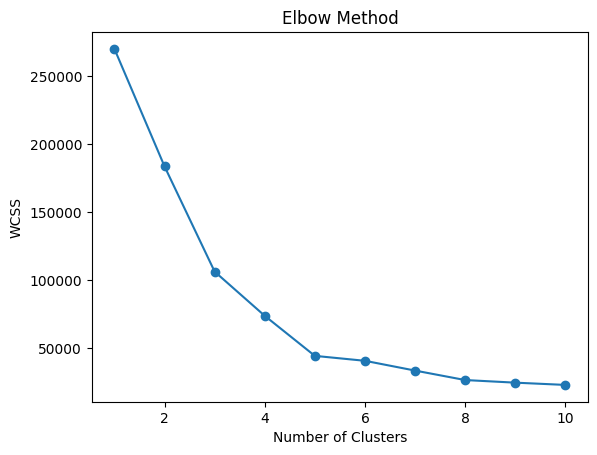

In [ ]:
# Plot Elbow Graph
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
# Apply K-Means with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X)


In [ ]:
# Visualize clusters
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=y_kmeans, cmap='rainbow')


In [ ]:
# Plot centroids
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            s=200,
            c='black',
            marker='X')

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, kmeans.labels_)

print("Silhouette Score :", score)